In [1]:
from google.colab import files
uploaded = files.upload()

Saving clubs1000_with_ranks_cleaned.xlsx to clubs1000_with_ranks_cleaned.xlsx
Saving fitness_clubs_dataset.xlsx to fitness_clubs_dataset.xlsx
Saving club_history.xlsx to club_history.xlsx


In [2]:
!pip install catboost openpyxl -q
!pip install pandas numpy scikit-learn matplotlib seaborn catboost openpyxl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_fscore_support, accuracy_score
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

In [4]:
CLUB_HISTORY_PATH = "club_history.xlsx"
CLUB_DATA_PATH = "clubs1000_with_ranks_cleaned.xlsx" # Or "clubs1000_with_ranks_cleaned (1).xlsx"
GYM_DATA_PATH = "fitness_clubs_dataset.xlsx"

In [5]:
MODEL_PATH = "catboost_gym_recommendation_model.joblib"
FEATURES_PATH = "gym_model_features.joblib"
OPTIMAL_THRESHOLD_PATH = "gym_optimal_threshold.joblib"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [6]:
try:
    interactions_df = pd.read_excel(CLUB_HISTORY_PATH)
    print(f"Loaded historical interactions: {interactions_df.shape}")
    print("Historical interactions columns:", interactions_df.columns.tolist())
except FileNotFoundError:
    print(f"Error: {CLUB_HISTORY_PATH} not found. Please ensure the file exists.")
    exit()

Loaded historical interactions: (37545, 20)
Historical interactions columns: ['InteractionID', 'ClubID', 'ClubName', 'PartnerID', 'PartnerType', 'PartnerName', 'InteractionType', 'InteractionDate', 'ContractValue', 'SatisfactionRating', 'FailureReason', 'ContractDuration', 'InteractionProbability', 'ClubBudget', 'PartnerExperience', 'PartnerLocation', 'PartnerSpecialization', 'GymCapacity', 'GymEquipment', 'GymServices']


In [7]:
try:
    clubs_df = pd.read_excel(CLUB_DATA_PATH)
    print(f"Loaded club data: {clubs_df.shape}")
    if 'Club ID' in clubs_df.columns:
        clubs_df.rename(columns={'Club ID': 'OriginalClubID'}, inplace=True)
    clubs_df['ClubID'] = range(1, len(clubs_df) + 1) # Align with ClubID in historical_interactions
    print("Club data columns:", clubs_df.columns.tolist())
except FileNotFoundError:
    print(f"Error: {CLUB_DATA_PATH} not found.")
    exit()


Loaded club data: (1000, 10)
Club data columns: ['OriginalClubID', 'Club Name', 'Stadium Capacity', 'Net Worth (million EUR)', 'Youth Academy Rating', 'Transfer Budget (million EUR)', 'Managerial Stability', 'Playing Style', 'Injury Records', 'Fan Base Size(million)', 'ClubID']


In [8]:
try:
    gyms_df = pd.read_excel(GYM_DATA_PATH) # Changed from CSV to Excel
    print(f"Loaded gym data: {gyms_df.shape}")
    if 'GYM_id' in gyms_df.columns: # Assuming original ID is 'GYM_id' as per generation script
        gyms_df.rename(columns={'GYM_id': 'OriginalGYMID'}, inplace=True)
    gyms_df['GYM_id'] = range(1, len(gyms_df) + 1) # Align with PartnerID in historical_interactions for gyms
    print("Gym data columns:", gyms_df.columns.tolist())
except FileNotFoundError:
    print(f"Error: {GYM_DATA_PATH} not found.")
    exit()
except Exception as e:
    print(f"Error loading gym data: {e}")
    exit()

Loaded gym data: (20000, 14)
Gym data columns: ['Gym Name', 'Location', 'Gym Type', 'Membership Capacity', 'Registered Players', 'Coaches & Trainers', 'Equipment Provided', 'Affiliated Clubs', 'Membership Fees', 'Contact Info', 'Facility Size', 'Additional Services', 'OriginalGYMID', 'Collaborated Clubs', 'GYM_id']


In [9]:
def count_items(item_string):
    if pd.isna(item_string) or item_string == 'None' or item_string == '':
        return 0
    # Handle cases where it might be a list string like "['item1', 'item2']"
    s = str(item_string).replace('[','').replace(']','').replace("'", "")
    return len([item for item in s.split(',') if item.strip()])

Engineered 'NumEquipmentProvided' from 'Equipment Provided'.
Engineered 'NumAdditionalServices' from 'Additional Services'.
Engineered 'GymReportedCollaborations' from 'Collaborated Clubs'.

--- Step 4: Preprocessing ---
Filtered for Gym interactions: (18409, 20)
Shape after merging with clubs: (18409, 31)
Shape after merging with gyms: (18409, 49)
Features (X) shape: (18409, 10)
Target (y) shape: (18409,)
Features selected for model: ['ClubBudget', 'PartnerExperience', 'Net Worth (million EUR)', 'Membership Capacity', 'NumEquipmentProvided', 'NumAdditionalServices', 'LocationMatch', 'Club_Location', 'Gym_Location', 'Gym Type']
Categorical features for model: ['Club_Location', 'Gym_Location', 'Gym Type']
Value counts for Target variable:
Target
1    0.840187
0    0.159813
Name: proportion, dtype: float64

--- Step 5: Train/Test Split ---
X_train shape: (13806, 10), X_test shape: (4603, 10)

--- Step 6: CatBoost Model Training ---


<ipython-input-10-795041962cf0>:123: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna('Unknown').astype(str) # CatBoost handles 'Unknown'
<ipython-input-10-795041962cf0>:123: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna('Unknown').astype(str) # CatBoost handles 'Unknown'
<ipython-input-10-795041962cf0>:123: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

0:	test: 0.5264823	best: 0.5264823 (0)	total: 76.2ms	remaining: 1m 16s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5543439612
bestIteration = 28

Shrink model to first 29 iterations.

--- Step 7: Model Evaluation ---
Accuracy (default 0.5 threshold): 0.8401042798175103
ROC AUC Score: 0.5543439611652669

Classification Report (default 0.5 threshold):
                precision    recall  f1-score   support

Not Successful       0.00      0.00      0.00       736
    Successful       0.84      1.00      0.91      3867

      accuracy                           0.84      4603
     macro avg       0.42      0.50      0.46      4603
  weighted avg       0.71      0.84      0.77      4603



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


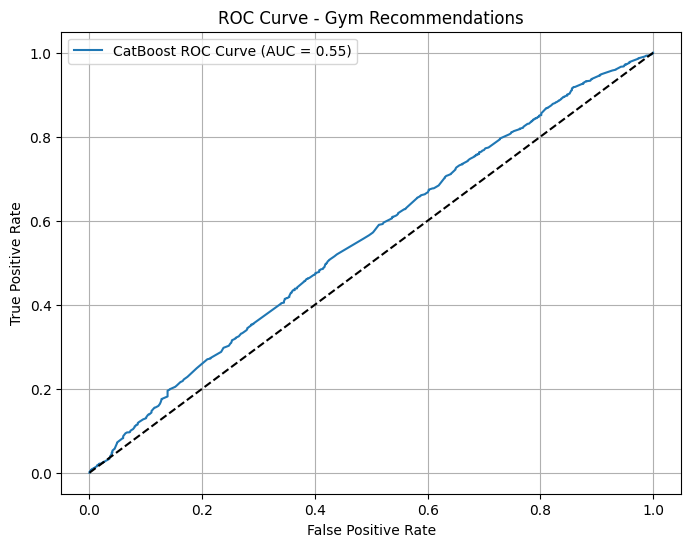


--- Step 8: Threshold Analysis ---
Optimal Threshold (max F1-score): 0.10
  Precision at optimal threshold: 0.84
  Recall at optimal threshold: 1.00
  F1-score at optimal threshold: 0.91
  Accuracy at optimal threshold: 0.84


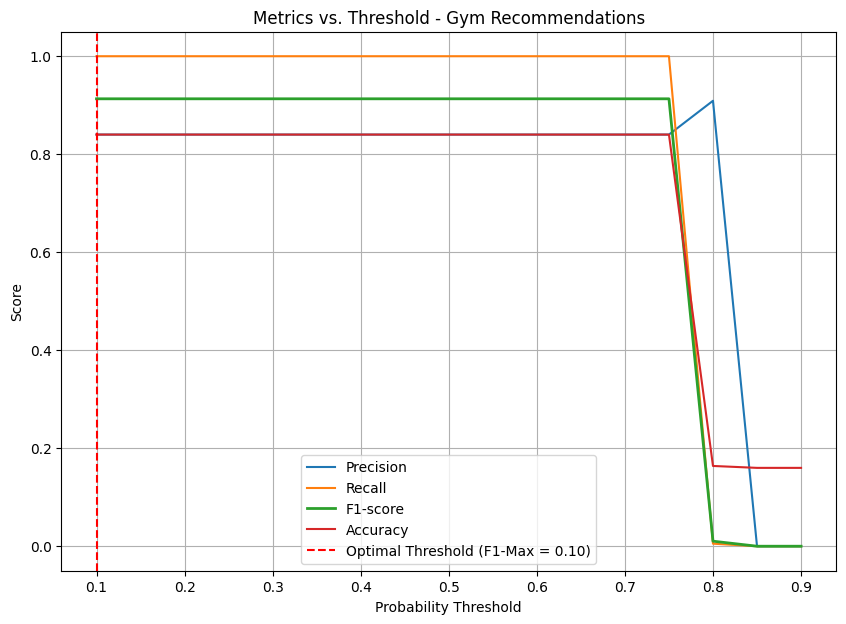


Classification Report (Optimal Threshold - Gyms):
                precision    recall  f1-score   support

Not Successful       0.00      0.00      0.00       736
    Successful       0.84      1.00      0.91      3867

      accuracy                           0.84      4603
     macro avg       0.42      0.50      0.46      4603
  weighted avg       0.71      0.84      0.77      4603


--- Step 9: Saving Artifacts ---
Model saved to catboost_gym_recommendation_model.joblib
Feature information saved to gym_model_features.joblib
Optimal threshold saved to gym_optimal_threshold.joblib

--- Step 10: Recommendation Functions ---

--- Step 11: Generate Recommendations (Demonstration for Gyms) ---

Recommendations of Gyms for Club ID: 1 (Real Madrid)


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


     GYMID                  GymName        GymLocation  ProbabilitySuccess
543    544  Victory Training Center       Paris, Spain            0.798432
348    349       Elite Fitness Club     London, France            0.798432
279    280       Elite Fitness Club  Berlin, Australia            0.797847
353    354       Elite Fitness Club         Berlin, UK            0.797847
375    376             Champion Gym    Berlin, Germany            0.797847

Recommendations of Clubs for Gym ID: 1 (Peak Performance Gym)
     ClubID           ClubName ClubLocation  ProbabilitySuccess
995     996       Kano Pillars      Unknown             0.81462
971     972    Petro de Luanda      Unknown             0.81462
371     372  Muangthong United      Unknown             0.81462
405     406       Kano Pillars      Unknown             0.81462
465     466        Alajuelense      Unknown             0.81462

--- Step 12: Feature Importance (Gym Model) ---
                   feature  importance
3      Membersh

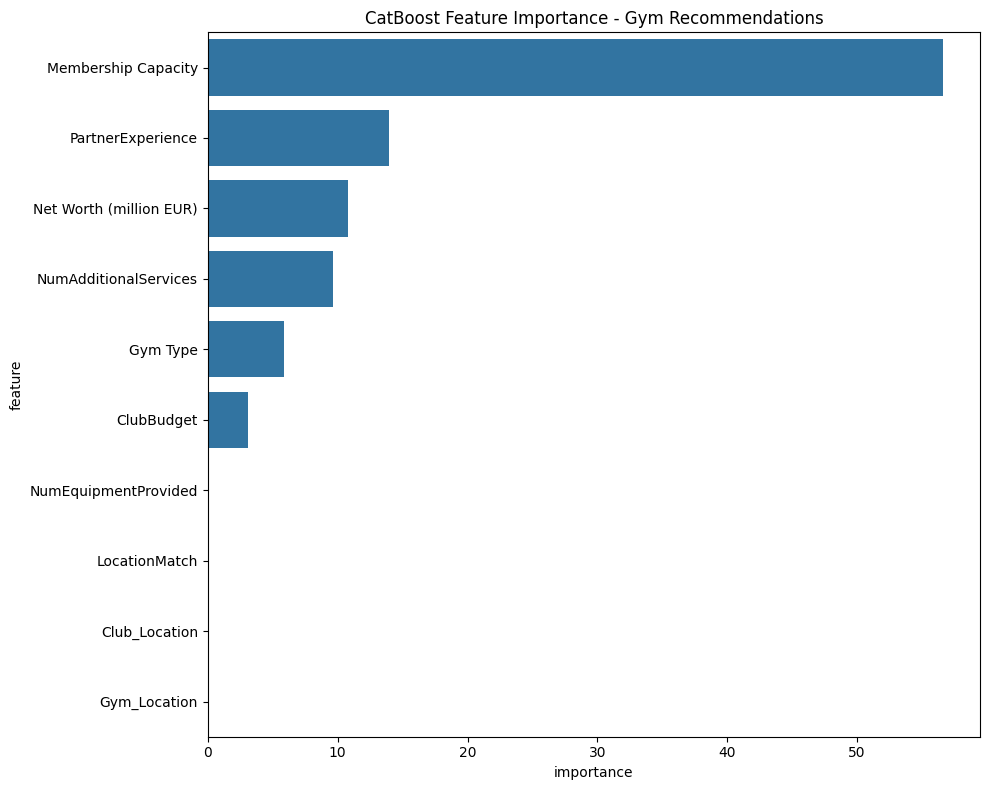


--- Gym Recommendation Script Finished ---


In [10]:
for col_name, new_col_name in [
    ('Equipment Provided', 'NumEquipmentProvided'),
    ('Additional Services', 'NumAdditionalServices'),
    ('Collaborated Clubs', 'GymReportedCollaborations') # Gym's overall collaboration history
]:
    if col_name in gyms_df.columns:
        gyms_df[new_col_name] = gyms_df[col_name].apply(count_items)
        print(f"Engineered '{new_col_name}' from '{col_name}'.")
    else:
        print(f"Warning: '{col_name}' not found in gym data. Setting '{new_col_name}' to 0.")
        gyms_df[new_col_name] = 0

# Standardize location column names and handle missing
if 'Location' not in clubs_df.columns and 'Club_Location' not in clubs_df.columns:
    print("Warning: 'Location' column not found in clubs_df. Creating placeholder 'Club_Location'. Geo-matching might be impacted.")
    clubs_df['Club_Location'] = 'Unknown'
elif 'Location' in clubs_df.columns:
    clubs_df.rename(columns={'Location': 'Club_Location'}, inplace=True)

if 'Location' not in gyms_df.columns and 'Gym_Location' not in gyms_df.columns:
    print("Warning: 'Location' column not found in gyms_df. Creating placeholder 'Gym_Location'. Geo-matching might be impacted.")
    gyms_df['Gym_Location'] = 'Unknown'
elif 'Location' in gyms_df.columns: # Assuming 'Location' is the column name in fitness_clubs_dataset.xlsx
    gyms_df.rename(columns={'Location': 'Gym_Location'}, inplace=True)


# --- Step 4: Preprocessing ---
print("\n--- Step 4: Preprocessing ---")

# Filter for gym interactions from historical data
gym_interactions_df = interactions_df[interactions_df['PartnerType'] == 'Gym'].copy()
print(f"Filtered for Gym interactions: {gym_interactions_df.shape}")

if gym_interactions_df.empty:
    print("Error: No 'Gym' interactions found in historical data. Exiting.")
    exit()

# Merge datasets
# Merge interactions with club data
merged_df = pd.merge(gym_interactions_df, clubs_df,
                     left_on='ClubID', right_on='ClubID',
                     suffixes=('_interaction', '_club'))
print(f"Shape after merging with clubs: {merged_df.shape}")

# Merge with gym data
# PartnerID from interaction_df should match the new sequential GYM_id
merged_df = pd.merge(merged_df, gyms_df,
                     left_on='PartnerID', right_on='GYM_id',
                     suffixes=('_club', '_gym')) # Suffixes adjust based on what's already there
print(f"Shape after merging with gyms: {merged_df.shape}")

# Refined Feature Engineering: Location Match
def simple_location_match(club_loc, gym_loc):
    if pd.isna(club_loc) or pd.isna(gym_loc) or club_loc == 'Unknown' or gym_loc == 'Unknown':
        return 0
    club_loc_str = str(club_loc).lower().strip()
    gym_loc_str = str(gym_loc).lower().strip()
    # For gyms, exact city or close proximity is more important.
    # The generation script used `club_loc_str == gym_loc_str` for gyms for a higher score.
    # Let's use a simple exact match for now, can be improved with geo-coordinates or city extraction.
    if club_loc_str == gym_loc_str:
        return 1
    # Could add partial match for broader regions if needed, e.g. country
    # elif any(part in gym_loc_str for part in club_loc_str.split()) or \
    #      any(part in club_loc_str for part in gym_loc_str.split()):
    #     return 0.5 # Partial match score
    return 0

merged_df['LocationMatch'] = merged_df.apply(
    lambda row: simple_location_match(row['Club_Location'], row['Gym_Location']), axis=1
)

# Define target variable
merged_df['Target'] = (merged_df['InteractionType'] == 'Successful').astype(int)

# Identify features (X) and target (y)
# Ensure required columns exist in merged_df after merges and feature engineering
feature_columns = [
    'ClubBudget',               # From historical interactions (originally from club)
    'PartnerExperience',        # From historical interactions (pair-specific history)
    'Net Worth (million EUR)',  # From clubs_df
    'Membership Capacity',      # From gyms_df
    'NumEquipmentProvided',     # Engineered from gyms_df
    'NumAdditionalServices',    # Engineered from gyms_df
    'LocationMatch',            # Engineered
    'Club_Location',            # Categorical, from clubs_df
    'Gym_Location',             # Categorical, from gyms_df
    'Gym Type'                  # Categorical, from gyms_df (ensure this name is correct in your gyms_df)
]
# Verify Gym Type column name
if 'Gym Type' not in gyms_df.columns and 'GymType' in gyms_df.columns: # common variations
    gyms_df.rename(columns={'GymType': 'Gym Type'}, inplace=True)
    merged_df.rename(columns={'GymType': 'Gym Type'}, inplace=True, errors='ignore')
elif 'Gym Type' not in merged_df.columns and 'GymType' in merged_df.columns:
     merged_df.rename(columns={'GymType': 'Gym Type'}, inplace=True, errors='ignore')

if 'Gym Type' not in gyms_df.columns and 'Gym Type' not in merged_df.columns:
    print("Warning: 'Gym Type' column not found in gym data or merged data. Removing from features.")
    if 'Gym Type' in feature_columns: feature_columns.remove('Gym Type')
    categorical_features = ['Club_Location', 'Gym_Location']
else:
    categorical_features = ['Club_Location', 'Gym_Location', 'Gym Type']


missing_model_cols = [col for col in feature_columns if col not in merged_df.columns]
if missing_model_cols:
    print(f"Error: Critical features for model are missing after merge: {missing_model_cols}")
    print("Available columns in merged_df:", merged_df.columns.tolist())
    exit()


X = merged_df[feature_columns]
y = merged_df['Target']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("Features selected for model:", feature_columns)
print("Categorical features for model:", categorical_features)

# Handle missing values
for col in X.columns:
    if col in categorical_features: # Check if it's in the dynamically set list
        X[col] = X[col].fillna('Unknown').astype(str) # CatBoost handles 'Unknown'
    elif pd.api.types.is_numeric_dtype(X[col]):
        if X[col].isnull().any():
            print(f"Warning: NaNs found in numerical feature '{col}'. Imputing with median.")
            X[col] = X[col].fillna(X[col].median()) # Impute numerical NaNs

print("Value counts for Target variable:")
print(y.value_counts(normalize=True))
if len(y.unique()) < 2:
    print("Error: Target variable has less than 2 unique classes. Cannot train a classifier.")
    exit()


# --- Step 5: Train/Test Split ---
print("\n--- Step 5: Train/Test Split ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

# Get indices of categorical features for CatBoost
categorical_features_indices = [X_train.columns.get_loc(col) for col in categorical_features if col in X_train.columns]


# --- Step 6: CatBoost Model Training ---
print("\n--- Step 6: CatBoost Model Training ---")
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=RANDOM_STATE,
    verbose=200,
    early_stopping_rounds=50,
    cat_features=categorical_features_indices
)

model.fit(X_train, y_train, eval_set=(X_test, y_test), plot=False)

# --- Step 7: Model Evaluation ---
print("\n--- Step 7: Model Evaluation ---")
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_class_default = model.predict(X_test)

print("Accuracy (default 0.5 threshold):", accuracy_score(y_test, y_pred_class_default))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report (default 0.5 threshold):")
print(classification_report(y_test, y_pred_class_default, target_names=['Not Successful', 'Successful']))

fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"CatBoost ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gym Recommendations')
plt.legend()
plt.grid(True)
plt.savefig("roc_curve_gym.png")
plt.show()

# --- Step 8: Threshold Analysis ---
print("\n--- Step 8: Threshold Analysis ---")
thresholds_range = np.arange(0.1, 0.91, 0.05)
precision_scores, recall_scores, f1_scores, accuracy_scores_thresh = [], [], [], []

for thresh in thresholds_range:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary', zero_division=0)
    acc = accuracy_score(y_test, y_pred_thresh)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    accuracy_scores_thresh.append(acc)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_range[optimal_idx]
print(f"Optimal Threshold (max F1-score): {optimal_threshold:.2f}")
print(f"  Precision at optimal threshold: {precision_scores[optimal_idx]:.2f}")
print(f"  Recall at optimal threshold: {recall_scores[optimal_idx]:.2f}")
print(f"  F1-score at optimal threshold: {f1_scores[optimal_idx]:.2f}")
print(f"  Accuracy at optimal threshold: {accuracy_scores_thresh[optimal_idx]:.2f}")

plt.figure(figsize=(10, 7))
plt.plot(thresholds_range, precision_scores, label='Precision')
plt.plot(thresholds_range, recall_scores, label='Recall')
plt.plot(thresholds_range, f1_scores, label='F1-score', linewidth=2)
plt.plot(thresholds_range, accuracy_scores_thresh, label='Accuracy')
plt.axvline(optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold (F1-Max = {optimal_threshold:.2f})')
plt.title('Metrics vs. Threshold - Gym Recommendations')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.savefig("threshold_analysis_gym.png")
plt.show()

y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
print("\nClassification Report (Optimal Threshold - Gyms):")
print(classification_report(y_test, y_pred_optimal, target_names=['Not Successful', 'Successful']))

# --- Step 9: Saving Artifacts ---
print("\n--- Step 9: Saving Artifacts ---")
joblib.dump(model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")
joblib.dump({'features': feature_columns, 'categorical_features': categorical_features}, FEATURES_PATH)
print(f"Feature information saved to {FEATURES_PATH}")
joblib.dump(optimal_threshold, OPTIMAL_THRESHOLD_PATH)
print(f"Optimal threshold saved to {OPTIMAL_THRESHOLD_PATH}")

# --- Step 10: Recommendation Functions ---
print("\n--- Step 10: Recommendation Functions ---")

def recommend_gyms_for_club(club_id, clubs_data, all_gyms_data, trained_model, model_features_info, threshold, top_n=5):
    target_club_series = clubs_data[clubs_data['ClubID'] == club_id]
    if target_club_series.empty:
        print(f"Club with ID {club_id} not found.")
        return pd.DataFrame()
    target_club = target_club_series.iloc[0]

    recommendation_candidates = []
    for _, gym in all_gyms_data.iterrows():
        candidate_features = {
            'ClubBudget': target_club.get('Transfer Budget (million EUR)', 0),
            'Net Worth (million EUR)': target_club.get('Net Worth (million EUR)', 0),
            'Club_Location': target_club.get('Club_Location', 'Unknown'),
            'Membership Capacity': gym.get('Membership Capacity', 0), # From gym_df
            'NumEquipmentProvided': gym.get('NumEquipmentProvided', 0), # From gym_df
            'NumAdditionalServices': gym.get('NumAdditionalServices', 0), # From gym_df
            'Gym_Location': gym.get('Gym_Location', 'Unknown'),
            'Gym Type': gym.get('Gym Type', 'Unknown'), # Ensure 'Gym Type' column name is correct
             # 'PartnerExperience' for a new pairing is unknown, could use gym's general experience or 0
            'PartnerExperience': gym.get('GymReportedCollaborations', 0), # Gym's overall exp
            'LocationMatch': simple_location_match(target_club.get('Club_Location'), gym.get('Gym_Location'))
        }
        current_candidate_data = {}
        for f_name in model_features_info['features']:
            current_candidate_data[f_name] = candidate_features.get(f_name)
            # Handle potential missing values for prediction time
            if pd.isna(current_candidate_data[f_name]):
                if f_name in model_features_info['categorical_features']:
                    current_candidate_data[f_name] = 'Unknown'
                else: # Numerical
                    current_candidate_data[f_name] = 0 # Or mean/median from training data

        recommendation_candidates.append({
            'GYMID': gym['GYM_id'], # Use the correct ID from gyms_df
            'GymName': gym['Gym Name'], # Assuming 'Gym Name' exists
            'GymLocation': gym['Gym_Location'],
            **current_candidate_data
        })

    if not recommendation_candidates: return pd.DataFrame()
    candidates_df = pd.DataFrame(recommendation_candidates)
    X_pred = candidates_df[model_features_info['features']].copy()
    # Ensure data types match training, esp. categorical as str
    for col in model_features_info['categorical_features']:
        if col in X_pred.columns:
            X_pred[col] = X_pred[col].astype(str).fillna('Unknown')


    candidates_df['ProbabilitySuccess'] = trained_model.predict_proba(X_pred)[:, 1]
    recommendations = candidates_df[candidates_df['ProbabilitySuccess'] >= threshold].sort_values(by='ProbabilitySuccess', ascending=False)
    return recommendations.head(top_n)[['GYMID', 'GymName', 'GymLocation', 'ProbabilitySuccess']]


def recommend_clubs_for_gym(gym_id, all_clubs_data, gyms_data, trained_model, model_features_info, threshold, top_n=5):
    target_gym_series = gyms_data[gyms_data['GYM_id'] == gym_id]
    if target_gym_series.empty:
        print(f"Gym with ID {gym_id} not found.")
        return pd.DataFrame()
    target_gym = target_gym_series.iloc[0]

    recommendation_candidates = []
    for _, club in all_clubs_data.iterrows():
        candidate_features = {
            'ClubBudget': club.get('Transfer Budget (million EUR)', 0),
            'Net Worth (million EUR)': club.get('Net Worth (million EUR)', 0),
            'Club_Location': club.get('Club_Location', 'Unknown'),
            'Membership Capacity': target_gym.get('Membership Capacity', 0),
            'NumEquipmentProvided': target_gym.get('NumEquipmentProvided', 0),
            'NumAdditionalServices': target_gym.get('NumAdditionalServices', 0),
            'Gym_Location': target_gym.get('Gym_Location', 'Unknown'),
            'Gym Type': target_gym.get('Gym Type', 'Unknown'),
            'PartnerExperience': target_gym.get('GymReportedCollaborations', 0), # Gym's overall exp
            'LocationMatch': simple_location_match(club.get('Club_Location'), target_gym.get('Gym_Location'))
        }
        current_candidate_data = {}
        for f_name in model_features_info['features']:
            current_candidate_data[f_name] = candidate_features.get(f_name)
            if pd.isna(current_candidate_data[f_name]):
                if f_name in model_features_info['categorical_features']:
                    current_candidate_data[f_name] = 'Unknown'
                else:
                    current_candidate_data[f_name] = 0

        recommendation_candidates.append({
            'ClubID': club['ClubID'],
            'ClubName': club['Club Name'],
            'ClubLocation': club['Club_Location'],
            **current_candidate_data
        })

    if not recommendation_candidates: return pd.DataFrame()
    candidates_df = pd.DataFrame(recommendation_candidates)
    X_pred = candidates_df[model_features_info['features']].copy()
    for col in model_features_info['categorical_features']:
        if col in X_pred.columns:
            X_pred[col] = X_pred[col].astype(str).fillna('Unknown')

    candidates_df['ProbabilitySuccess'] = trained_model.predict_proba(X_pred)[:, 1]
    recommendations = candidates_df[candidates_df['ProbabilitySuccess'] >= threshold].sort_values(by='ProbabilitySuccess', ascending=False)
    return recommendations.head(top_n)[['ClubID', 'ClubName', 'ClubLocation', 'ProbabilitySuccess']]


# --- Step 11: Generate Recommendations (Demonstration) ---
print("\n--- Step 11: Generate Recommendations (Demonstration for Gyms) ---")
# Ensure clubs_df and gyms_df have been loaded and processed
# model_features_info would be {'features': feature_columns, 'categorical_features': categorical_features}

if not clubs_df.empty and not gyms_df.empty:
    example_club_id = clubs_df['ClubID'].iloc[0]
    club_name_display = clubs_df[clubs_df['ClubID']==example_club_id]['Club Name'].values[0]
    print(f"\nRecommendations of Gyms for Club ID: {example_club_id} ({club_name_display})")
    gym_recs_for_club = recommend_gyms_for_club(example_club_id, clubs_df, gyms_df, model, {'features': feature_columns, 'categorical_features': categorical_features}, optimal_threshold)
    if not gym_recs_for_club.empty:
        print(gym_recs_for_club)
    else:
        print("No gyms recommended for this club at the current threshold.")

    example_gym_id = gyms_df['GYM_id'].iloc[0]
    gym_name_display = gyms_df[gyms_df['GYM_id']==example_gym_id]['Gym Name'].values[0]
    print(f"\nRecommendations of Clubs for Gym ID: {example_gym_id} ({gym_name_display})")
    club_recs_for_gym = recommend_clubs_for_gym(example_gym_id, clubs_df, gyms_df, model, {'features': feature_columns, 'categorical_features': categorical_features}, optimal_threshold)
    if not club_recs_for_gym.empty:
        print(club_recs_for_gym)
    else:
        print("No clubs recommended for this gym at the current threshold.")
else:
    print("Clubs or Gyms data is empty, cannot generate example recommendations.")


# --- Step 12: Feature Importance ---
print("\n--- Step 12: Feature Importance (Gym Model) ---")
if hasattr(model, 'get_feature_importance'):
    feature_importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.get_feature_importance()
    }).sort_values(by='importance', ascending=False)
    print(feature_importance_df)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=feature_importance_df)
    plt.title('CatBoost Feature Importance - Gym Recommendations')
    plt.tight_layout()
    plt.savefig("feature_importance_gym.png")
    plt.show()
else:
    print("Could not retrieve feature importance from the model.")

print("\n--- Gym Recommendation Script Finished ---")